     Part 1 - KNN Cross-validation (5-fold)

k           Acc      Err     Prec      Rec
------------------------------------------
1        0.9081   0.0919   0.8823   0.8852
3        0.9093   0.0907   0.8940   0.8742
5        0.9052   0.0948   0.8957   0.8602
7        0.9020   0.0980   0.8977   0.8484
9        0.9017   0.0983   0.8994   0.8455
11       0.9023   0.0977   0.9056   0.8403
15       0.8977   0.1023   0.9044   0.8286
21       0.8913   0.1087   0.9028   0.8124

Best k = 3 (lowest CV error = 0.0907)

part 2 - Classifier Comparison (train and test)

Classifier                        Acc      Err     Prec      Rec
------------------------------------------------------------
    Logistic Regression (train) Acc=0.9290 Err=0.0710 Prec=0.9278 rec=0.8889
    Logistic Regression (test) Acc=0.9279 Err=0.0721 Prec=0.9304 rec=0.8833

    LDA (train)               Acc=0.8910 Err=0.1090 Prec=0.9183 rec=0.7940
    LDA (test)                Acc=0.8844 Err=0.1156 Prec=0.9105 rec=0.7841

    K

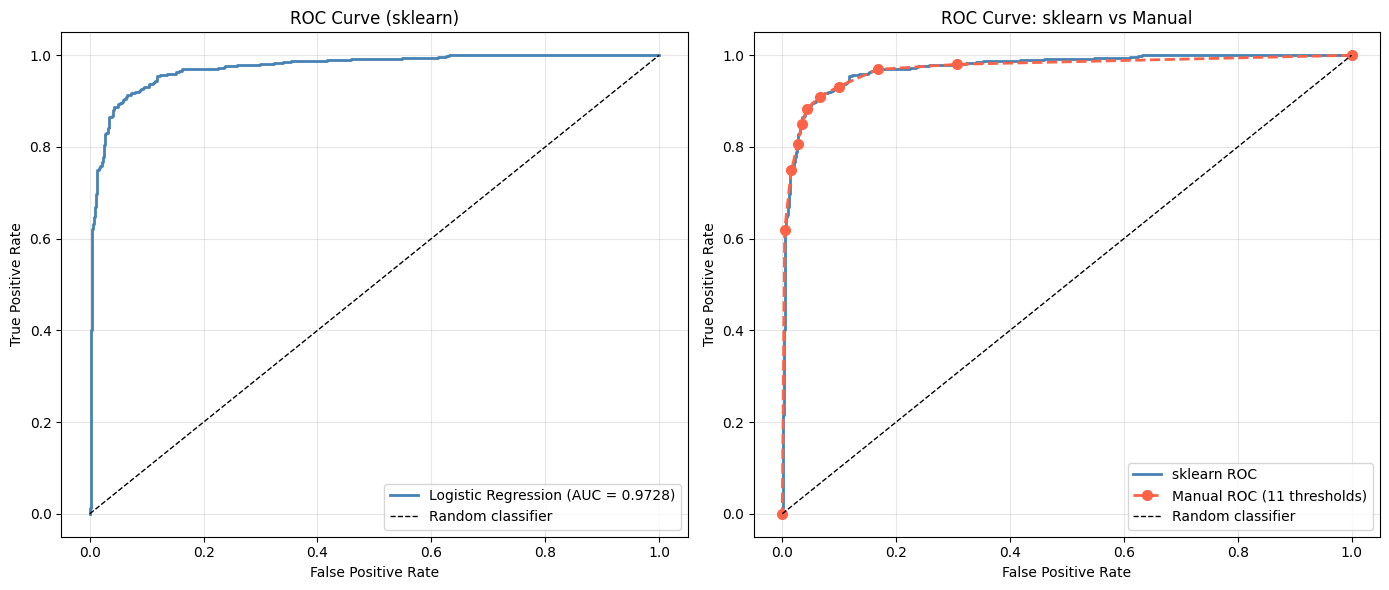


  Part 4 - Manual vs sklearn ROC

   Threshold      FPR      TPR
  ----------------------------
      0.0000   1.0000   1.0000
      0.1000   0.3070   0.9802
      0.2000   0.1679   0.9692
      0.3000   0.0990   0.9317
      0.4000   0.0660   0.9097
      0.5000   0.0430   0.8833
      0.6000   0.0344   0.8502
      0.7000   0.0273   0.8062
      0.8000   0.0158   0.7489
      0.9000   0.0043   0.6189
      1.0000   0.0000   0.0000


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Load in the data
data_url = '../spambase_data/spambase.data'
names_url = '../spambase_data/spambase.names'

# parse the feature names from the .names file
feature_names = []
with open(names_url, "r") as f:
    for line in f:
        line = line.strip()
        if ':' in line and not line.startswith("|"):
            feature_names.append(line.split(":")[0].strip())
feature_names.append("label") # last column is the class label

df = pd.read_csv(data_url, header=None, names=feature_names)
x = df.drop("label", axis=1).values
y = df["label"].values
names = feature_names[:-1]

# Create the train test split for the data
x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y 
)

# Train the logistic regrerssion model
scaler = StandardScaler()
x_tr = scaler.fit_transform(x_tr)
x_te = scaler.transform(x_te)

# Metrics helper
def metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    err = 1 - acc
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    return acc, err, prec, rec

def print_metrics(label, y_true, y_pred):
    acc, err, prec, rec = metrics(y_true, y_pred)
    print(f"    {label:<25} Acc={acc:.4f} Err={err:.4f} Prec={prec:.4f} rec={rec:.4f}")

# cross validation for KNN
print("="*60)
print("     Part 1 - KNN Cross-validation (5-fold)")
print("="*60)

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
cv_results = {}

print(f"\n{'k':<6} {'Acc':>8} {'Err':>8} {'Prec':>8} {'Rec':>8}")
print("-"*42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    acc_scores = cross_val_score(knn, x_tr, y_tr, cv=5, scoring="accuracy")
    prec_scores = cross_val_score(knn, x_tr, y_tr, cv=5, scoring="precision")
    rec_scores = cross_val_score(knn, x_tr, y_tr, cv=5, scoring="recall")
    acc = acc_scores.mean()
    err = 1 - acc
    prec = prec_scores.mean()
    rec = rec_scores.mean()
    cv_results[k] = (acc, err, prec, rec)
    print(f"{k:<6} {acc:>8.4f} {err:>8.4f} {prec:>8.4f} {rec:>8.4f}")

best_k = min(cv_results, key=lambda k: cv_results[k][1])
print(f"\nBest k = {best_k} (lowest CV error = {cv_results[best_k][1]:.4f})")

# Part 2 train all classifiers and compare
print(f"\n{'='*65}")
print(  "part 2 - Classifier Comparison (train and test)")
print(f"{'='*65}")

lr = LogisticRegression(max_iter=2000, solver="lbfgs", C=1.0, random_state=42)
lda = LinearDiscriminantAnalysis()
knn = KNeighborsClassifier(n_neighbors=best_k)

lr.fit(x_tr, y_tr)
lda.fit(x_tr, y_tr)
knn.fit(x_tr, y_tr)

print(f"\n{'Classifier':<28} {'Acc':>8} {'Err':>8} {'Prec':>8} {'Rec':>8}")
print("-"*60)
for name, clf, in [("Logistic Regression", lr), ("LDA", lda), ("KNN", knn)]:
    print_metrics(f"{name} (train)", y_tr, clf.predict(x_tr))
    print_metrics(f"{name} (test)", y_te, clf.predict(x_te))
    print()

# part 3: ROC curve with sklearn
ig, axes = plt.subplots(1, 2, figsize=(14, 6))

lr_probs = lr.predict_proba(x_te)[:, 1]
fpr_sk, tpr_sk, _ = roc_curve(y_te, lr_probs)
roc_auc = auc(fpr_sk, tpr_sk)

ax = axes[0]
ax.plot(fpr_sk, tpr_sk, color="steelblue", lw=2,
        label=f"Logistic Regression (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (sklearn)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

print(f"\n{'='*65}")
print("  Part 3 - ROC Curve (sklearn)")
print(f"{'='*65}")
print(f"\n  AUC = {roc_auc:.4f}")

# part 4: ROC curve without sklearn
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
fprs, tprs = [], []

for T in thresholds:
    y_pred_T = (lr_probs >= T).astype(int)
    tp = np.sum((y_pred_T == 1) & (y_te == 1))
    fp = np.sum((y_pred_T == 1) & (y_te == 0))
    tn = np.sum((y_pred_T == 0) & (y_te == 0))
    fn = np.sum((y_pred_T == 0) & (y_te == 1))
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fprs.append(fpr)
    tprs.append(tpr)

ax = axes[1]
ax.plot(fpr_sk, tpr_sk, color="steelblue", lw=2, label="sklearn ROC")
ax.plot(fprs, tprs, "o--", color="tomato", lw=2,
        markersize=7, label="Manual ROC (11 thresholds)")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: sklearn vs Manual")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

print(f"\n{'='*65}")
print("  Part 4 - Manual vs sklearn ROC")
print(f"{'='*65}")
print(f"\n  {'Threshold':>10} {'FPR':>8} {'TPR':>8}")
print("  " + "-" * 28)
display_thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for T, fx, tx in zip(thresholds, fprs, tprs):
    if round(T, 1) in display_thresholds:
        print(f"  {T:>10.4f} {fx:>8.4f} {tx:>8.4f}")

# observations
- The sklearn ROC is a smooth curve computed over all unique predicted probability values as thresholds (~1151 points), giving fine-grained resolution
- The manual ROC uses only 11 evenly spaced thresholds, producing a coarse, piecewise-linear approximation with visible steps.
- To make them more similar: use more threshold values (e.g. every 0.01 or every unique predicted probability), which would increase resolution and make the manual curve approach the sklearn curve.